# 01 - RAN Environment Sanity Check
Owner: Shashank (env) + Shreya (verification)

Checks:
- env resets correctly
- obs shapes match expected dims
- UEs move across steps
- rewards are valid scalars
- visualize UE positions + RSRP over time

In [8]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from collections import defaultdict

from env.ran_env import RANEnv
from agents.agent_manager import AgentManager

# constants
NUM_CELLS = 7
OBS_DIM = 16
ACTION_LABELS = ['STAY', 'PREPARE_HO', 'TRIGGER_HO']

env = RANEnv(num_cells=NUM_CELLS, num_ues=10)
manager = AgentManager(num_agents=NUM_CELLS, obs_dim=OBS_DIM)
agent_ids = env.possible_agents

sys.path.insert(0, os.path.abspath('..'))
print('Setup complete')

Setup complete


In [9]:
# reset check 
obs, info = env.reset(seed=42)

print('Obs keys:', list(obs.keys()))
print('Obs dim per agent:', obs[agent_ids[0]].shape)

# IMPORTANT: expected shape is (16,) = 7 rsrp + 7 load + 1 velocity + 1 interference
expected_dim = 16
for agent in agent_ids:
    assert obs[agent].shape == (expected_dim,), f'Shape mismatch for {agent}'
print('All obs shapes OK')

Obs keys: ['cell_0', 'cell_1', 'cell_2', 'cell_3', 'cell_4', 'cell_5', 'cell_6']
Obs dim per agent: (16,)
All obs shapes OK


In [10]:
# step check
# random actions for all agents
actions = {agent: env.action_space(agent).sample() for agent in agent_ids}
obs, rewards, terminations, truncations, info = env.step(actions)

print('Rewards:', rewards)
print('Metrics:', info[agent_ids[0]]['metrics'])

# rewards must be floats
for agent in agent_ids:
    assert isinstance(rewards[agent], float), f'Reward not float for {agent}'
print('All rewards valid')

Rewards: {'cell_0': 1.0, 'cell_1': 0.5, 'cell_2': 0.6, 'cell_3': 1.0, 'cell_4': 0.0, 'cell_5': 0.5, 'cell_6': 1.7999999999999998}
Metrics: {'ho_triggered': 0, 'ho_success': 0, 'ping_pong': 0, 'missed_ho': 0}
All rewards valid


In [11]:
# rollout + track UE serving cells over time
env.reset(seed=42)
serving_cell_history = {ue.ue_id: [] for ue in env.ues}
rsrp_history = {ue.ue_id: [] for ue in env.ues}
reward_history = []

for step in range(100):
    actions = {agent: env.action_space(agent).sample() for agent in agent_ids}
    obs, rewards, terminations, truncations, info = env.step(actions)

    for ue in env.ues:
        serving_cell_history[ue.ue_id].append(ue.serving_cell)
        rsrp_history[ue.ue_id].append(max(ue.rsrp))

    reward_history.append(np.mean(list(rewards.values())))

print('Rollout complete')

Rollout complete


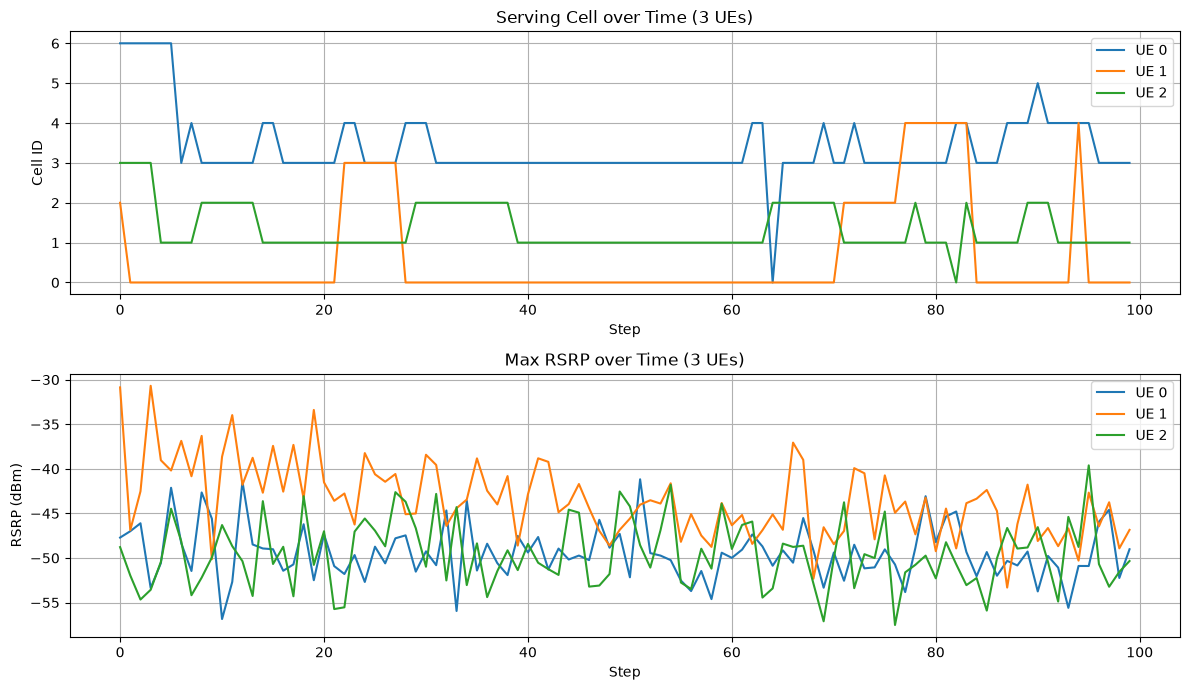

In [12]:
# plot: serving cell over time for 3 UEs
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

for ue_id in range(3):
    axes[0].plot(serving_cell_history[ue_id], label=f'UE {ue_id}')
axes[0].set_title('Serving Cell over Time (3 UEs)')
axes[0].set_ylabel('Cell ID')
axes[0].set_xlabel('Step')
axes[0].legend()
axes[0].grid(True)

# plot: RSRP over time
for ue_id in range(3):
    axes[1].plot(rsrp_history[ue_id], label=f'UE {ue_id}')
axes[1].set_title('Max RSRP over Time (3 UEs)')
axes[1].set_ylabel('RSRP (dBm)')
axes[1].set_xlabel('Step')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../results/plots/env_sanity_check.png', dpi=150)
plt.show()

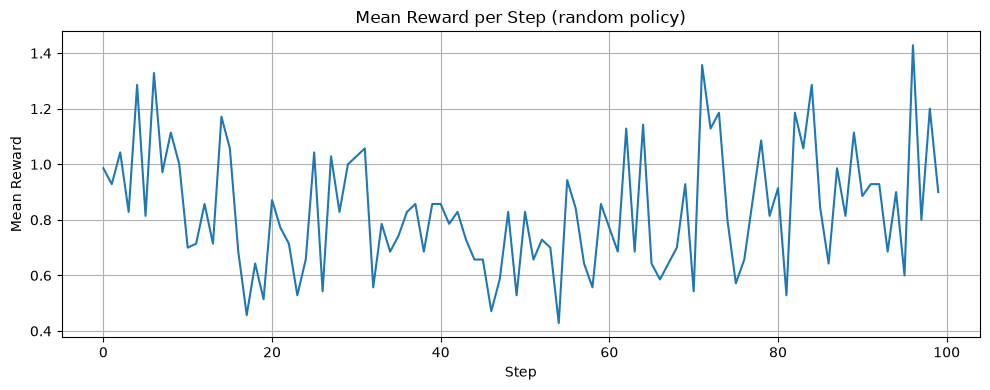

In [13]:
# plot: mean reward over steps 
plt.figure(figsize=(10, 4))
plt.plot(reward_history)
plt.title('Mean Reward per Step (random policy)')
plt.xlabel('Step')
plt.ylabel('Mean Reward')
plt.grid(True)
plt.tight_layout()
plt.savefig('../results/plots/env_random_reward.png', dpi=150)
plt.show()